In [22]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.constants as cte
from tqdm import tqdm

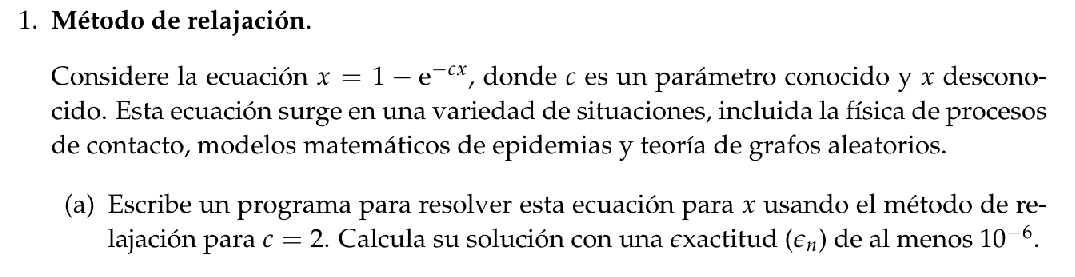

In [23]:
#metodo de relajación

In [24]:
def f1(x,c):
    return 1-np.e**(-c*x)
    #función que queremos encontrar su raiz

In [25]:
def df1(x,c):
    return c*np.e**(-c*x) #derivada de la función

In [26]:
c = 2 
error = 1.0
x0 = 200 #valores iniciales 
while error > 1e-6: #codigo del metodo de relajación
        x1 = f1(x0,c) #buscamos el valor que sigue
        error = abs((x1-x0)/(1-1/df1(x1,c))) # evaluamos la expresión del error
        x0 = x1 #el x0 pasa a ser x1
resul = np.round(x0,6) #obtenemos el resultado redondeado a 6 cifras despues del punto decimal

In [27]:
f1(resul,c) #obtenemos el valor al evaluar
dif = resul - f1(resul,c)

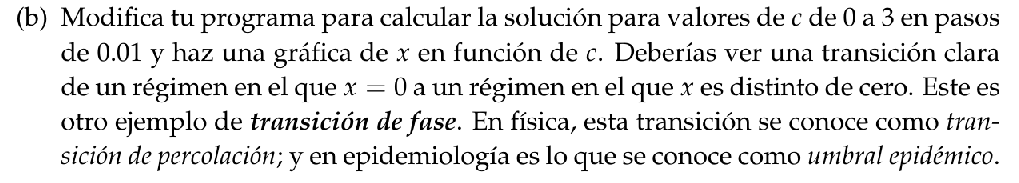

In [28]:
C = np.arange(0,3,0.01)
valores = []
for c in tqdm(C):
    error = 1.0
    x0 = 0.5
    while error > 1e-6:
        x1 = f1(x0,c)
        error = abs((x1-x0)/(1-1/df1(x1,c)))
        x0 = x1
    valores.append(x0)

  0%|                                                   | 0/300 [00:00<?, ?it/s]/tmp/ipykernel_7947/2716409139.py:8: RuntimeWarning: divide by zero encountered in scalar divide
  error = abs((x1-x0)/(1-1/df1(x1,c)))
100%|████████████████████████████████████████| 300/300 [00:01<00:00, 185.44it/s]


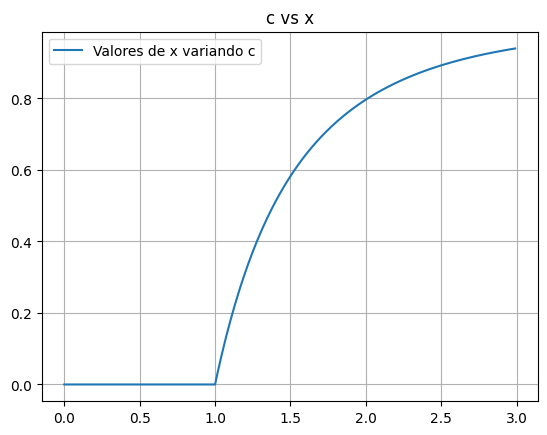

In [29]:
plt.title('c vs x')
plt.plot(C,valores, label = 'Valores de x variando c')
plt.legend()
plt.grid()

## Problema 2

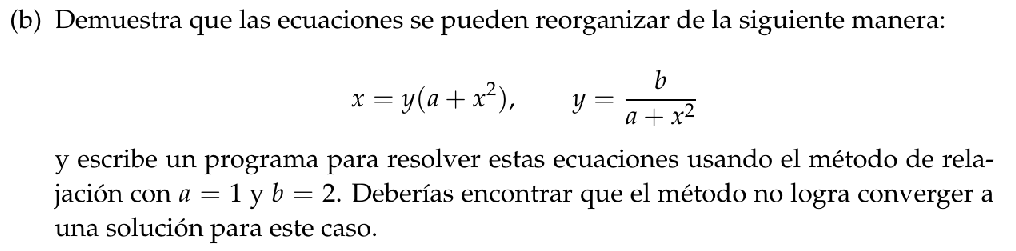

In [9]:
def eq1(x,y,a): #definimos nuestras ecuaciones como en el inciso b)
    return y*(a+x**2)
def eq2(x,a,b):
    return b/(a+x**2)

In [10]:
a = 1 #definimos las condiciones iniciales
b = 2
error = 1.0
x0 = 0
y0 = 0.5
for i in range(50): #realizamos 50 veces la iteración de relajación
    if (x0 < 1e100 and y0 < 1e100):
        x1 = eq1(x0,y0,a)
        y1 = eq2(x0,a,b)
        x0 = x1
        y0 = y1
        print(y0,x0)
        
    else:
        break


print(eq2(x0,a,b),eq1(x0,y0,a))

2.0 0.5
1.6 2.5
0.27586206896551724 11.600000000000001
0.014753614635585716 37.39586206896553
0.0014291323631453428 20.646953376823465
0.004680588631001059 0.6106635194042626
1.4567597994379615 0.00642602662814679
1.9999174157737667 1.456819954612318
0.6405484365143596 6.244390905570288
0.050009479569943095 25.617080682413047
0.0030430523930799072 32.867971437933704
0.0018496193844695313 3.2904633446547176
0.16910246046553032 0.02187572409505604
1.9990433631866025 0.16918338399220137
1.9443469241221696 2.0562620161925342
0.3825398499780061 10.165460797006945
0.01916873014886948 39.91290471586791
0.0012546736886158139 30.55572189453799
0.0021398335416403127 1.1726834486892193
0.8420391512677362 0.005082503677931545
1.9999483376472615 0.8420609026914273
1.1702294353618163 3.418044833283328
0.15769101893949042 14.842055600019423
0.009038052324651104 34.89491170777831
0.001641153751212919 11.014266418330882
0.016351349326423962 0.20073618616425695
1.9225315592228274 0.01701022721627925
1.9

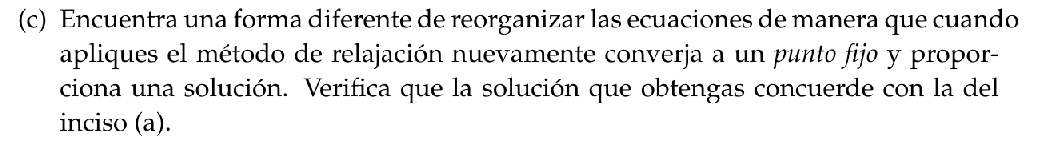

In [34]:
def fy3(x,a): 
    return x/(x**2+a)

In [35]:
def fx4(y,a,b):
    return np.sqrt(b/y - a)

si el error es la derivada de f es el gradiente, y f = (fx4,fy3) fx no depende de x y fy no depende de y, pero tomaremos la derivada como el gradiente de las funciones fx y fy.
es decir, f' = ($\nabla fx4, \nabla fy3$)

In [36]:
def dxfy3(x,a): 
    return -2*x**2/(x**2+a)**2

In [37]:
def dyfx4(y,a,b):
    return (1/2)*(-b/y**2)/np.sqrt(b/y - a)

In [43]:
a = 1
b = 2
error = 1
x0 = 5
y0 = 1
while error > 1e-7:
    if b/y0 < a:
        print('cambia y0 por algún valor donde b/y0 > a')
        break
    else:
        v0 = np.array([x0,y0]) #creamos un vector v0 como (x0,y0)
        y1 = fy3(x0,a) #obtenemos los nuevos valores
        x1 = fx4(y0,a,b) 
        v1 = np.array([x1,y1]) #el vector v1 es el vector con los nuevos valores (x1,y1)
        vdf = np.array([dyfx4(y0,a,b),dxfy3(x0,a)]) #obtenemos el vector derivada de f
        df = np.sqrt(np.dot(vdf,vdf)) #obtenemos la norma
        verror = (v1-v0)/(1-1/df)#aplicamos el error pero en forma vectorial por ello lleva al inicio una v
        error = np.sqrt(np.dot(verror,verror)) #entonces el error es la norma de dicho vector
        x0 = x1 #cambiamos el x0 y y0 por x1 y y1.
        y0 = y1
print(y0,x0) # imprimimos los valores.

0.4000000017703856 2.0000000239911544


## Problema 3

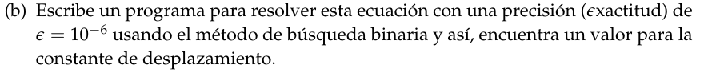


In [47]:
def Ip(x): #función obtenida 
    return 5*np.e**(-x) + x - 5

In [48]:
def binaria(g,x1,x2,min_error):
    'Método de busqueda de raices donde x1 < x2, calcula mediante biyecciones, g es una función de una variable, min_error es el valor de error que necesitamos'
    'puede ser 1e-1 es decir un error de 0.1 del valor de la raiz'
    pendiente = (g(x2)-g(x1))/(x2-x1) #calculamos la pendiente
    raiz = 0 #raiz es 0 al inicio
    i = 0 #cantidad de iteraciones
    error = 10 #error igual a 10 simplemente pq podemos obtener un error min de 1 pero eso no nos sirve.
    if pendiente > 0: #si la pendiente es positiva 
        if (g(x1) < 0 and g(x2) > 0): # si g(x1) < 0 y g(x2)>0 significa que pasamos por lo menos por una raiz 
            while error > min_error:
               raiz = (x2+x1)/2
               ev = g(raiz)
               if ev < 0:
                   x1 = raiz
               elif g(raiz) == 0:
                   error = 0
               else:
                    x2 = raiz
               error = abs((x1-x2)/(2**i))     
               i += 1
        else: #si ambos son negativos o positivos entonces la aproximación por una recta no pasa por ninguna raiz
            raiz = print('el intervalo no pasa por una raíz')
    elif pendiente < 0: #analogamente con una pendiente negativa
        if (g(x1) > 0 and g(x2) < 0):
            while error > min_error:
                raiz = (x2+x1)/2
                ev = g(raiz)
                if ev > 0:
                    x1 = raiz
    
                elif ev == 0:
                    error = 0    
                else:
                    x2 = raiz
                error = abs((x1-x2)/(2**i))
                i += 1
        else:
            raiz = print('el intervalo no pasa por una raíz')
            
    return raiz


In [49]:
X = np.linspace(-1,10,100)

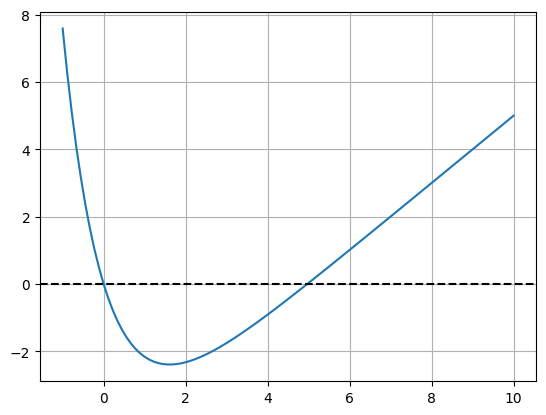

In [53]:
plt.plot(X,Ip(X))
plt.axhline(y=0, c = 'k' , ls = '--')
plt.grid()
#Podemos notar que hay dos raices 

In [17]:
raiz1 = binaria(Ip,-1,1,1e-6) #raiz 1

In [18]:
raiz2 = binaria(Ip,1,10,1e-6) # raiz 2


In [19]:
x = np.round(raiz2,6) #la raiz 2 es la que nos interesa en el problema por ello redondeamos a 6 decimales

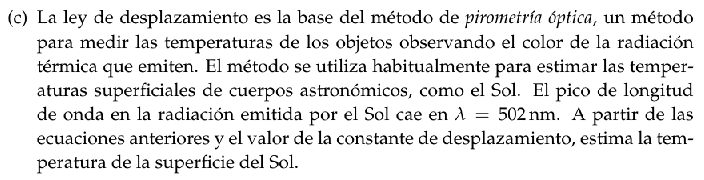

In [20]:
b = (cte.h*cte.c)/(cte.k*x) #calculamos b

In [21]:
Ldo = 502*1e-9 # valor de la longitud de onda (Ldo)

In [23]:
T = b/Ldo #temperatura del sol

In [24]:
print('La temperatura del sol es aprox. de', T, 'K')

La temperatura del sol es aprox. de 5772.626433732264 K


## Problema 4

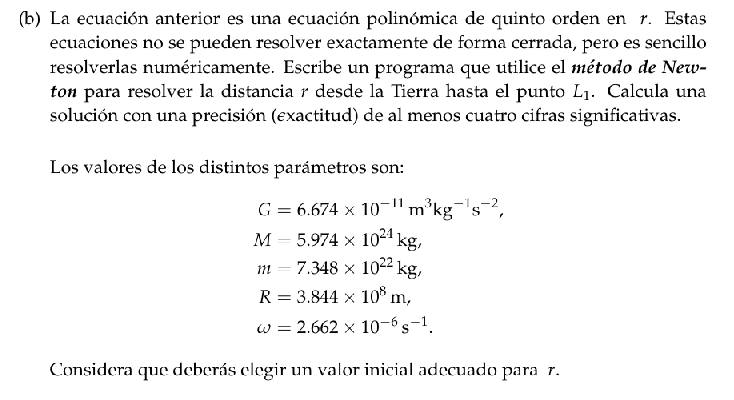 \
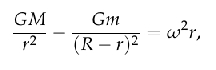 \
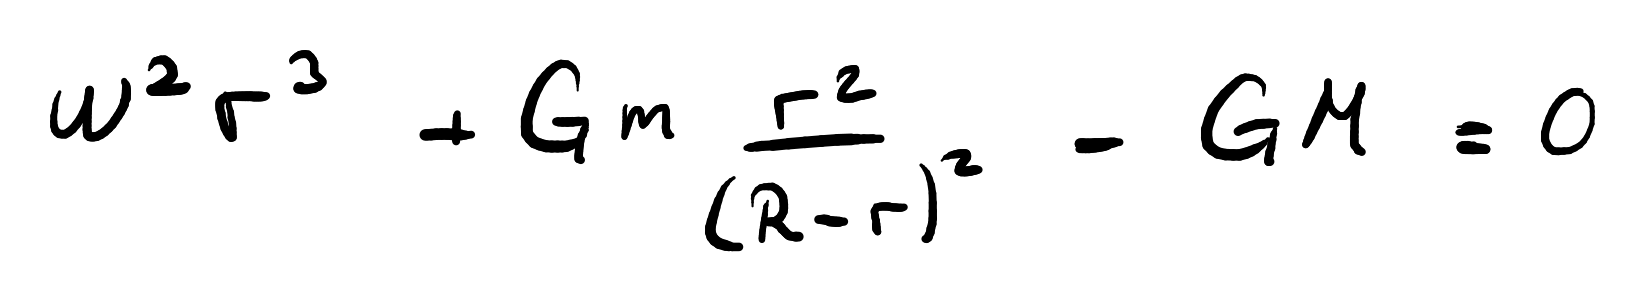

In [ ]:
## Método de Newton
def puntoL1(x):#función que debe cumplir L1
    w = 2.662*1e-6 
    M = 5.974*1e24
    m = 7.348*1e22
    R = 3.844*1e8
    G = cte.G
    return (w**2)*(x**3)+G*m*(x**2)/(R-x)**2-G*M

In [ ]:
def devL1(x): #derivada de L1
    w = 2.662*1e-6 
    M = 5.974*1e24
    m = 7.348*1e22
    R = 3.844*1e8
    G = cte.G
    return 3*(w**2)*(x**2)+ (2*x*G*m)*(1+x/(R-x))/(R-x)**2

In [ ]:
def raizNewton(f,df,x0,min_error): #metodo de newton
    error = 1 #definimos el error al menos como 1 hasta que se proponga un x0
    raiz = x0 #la raiz al inicio es x0
    while error > min_error: #mientras el error sea mayor a min_error entonces realiza el proceso
        x1 = raiz - f(raiz)/df(raiz) #la nueva x1 es igual a la formula del metodo
        error = abs(x1-raiz) #el error es la diferencia del nuevo valor y del anterior valor
        raiz = x1 #ahora la raiz es el nuevo valor
    return raiz

In [ ]:
r = raizNewton(puntoL1,devL1,1e5,1e-4) # valor de la distancia del punto L1

In [ ]:
radiotierra = 6371*1e3 #valor del radio de la tierra

In [ ]:
r - radiotierra #valor de la distancia de L1 (que esta desde el centro de la tierra) menos el radio de la tierra.

Por lo tanto la distancia del satélite al centro de al tierra para estar en el punto L1 debe ser 326,046,378.7639 metros o $3.26*10⁸ \ m$  que desde la superficie de la tierra equivale aprox. 319,675,378 m o $3.19 * 10⁸ \ m $